In [1]:
from segment_anything import sam_model_registry, SamPredictor
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
from skimage import io as io
import os
from IPython.display import clear_output

In [2]:
# load checkpoints
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
predictor = SamPredictor(sam)

In [3]:
# helper functions to visualize
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_points(coords, labels, ax, marker_size=100):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='.', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='.', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2)) 

In [4]:
def get_mask(input_point, input_label = np.array([1, 1, 0, 0])):
    # point mask
    masks, scores, logits = predictor.predict(
            point_coords=input_point,
            point_labels=input_label,
            multimask_output=True
            )
        # mask with background pixel
    mask_input = logits[np.argmax(scores), :, :]
    masks, _, _ = predictor.predict(
            point_coords=input_point,
            point_labels=input_label,
            mask_input=mask_input[None, :, :],
            multimask_output=False,
            )
# show mask
    plt.figure(figsize=(5, 5))
    fig = plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    show_mask(masks, plt.gca())
    show_points(input_point, input_label, plt.gca())
    plt.axis('on')
    plt.show()
    return masks

In [5]:
def click_event(event, x, y, flags, params):
    global new_label
    global new_point
    global image
    # left click add foreground point
    if event == cv2.EVENT_LBUTTONDOWN:
        new_label = 1
        new_point = [x,y]
    # right click add background point
    if event == cv2.EVENT_RBUTTONDOWN:
        new_label = 0
        new_point = [x,y]
    

# Sample Usage

In [50]:
leaves = []

directory = '../../../../Desktop/2024_stripe_rust/TH1R1_top/'
files = sorted(os.listdir(directory))[:]
#files = ['Avocet+Yr15-R2-3_Green SkEye iPhone 32_20251126_123634_000.jpeg']

for file in files[-3:]:
    leaf = []
    leaf.append(directory+file)
    leaf.append(file)
    leaves.append(leaf)
print(leaves[0])

['../../../../Desktop/2024_stripe_rust/TH1R1_top/TH1R1_BigLab_iPhone14_20240505_234757_0500.jpeg', 'TH1R1_BigLab_iPhone14_20240505_234757_0500.jpeg']


../../../../Desktop/2024_stripe_rust/TH1R1_top/TH1R1_BigLab_iPhone14_20240507_024758_3680.jpeg


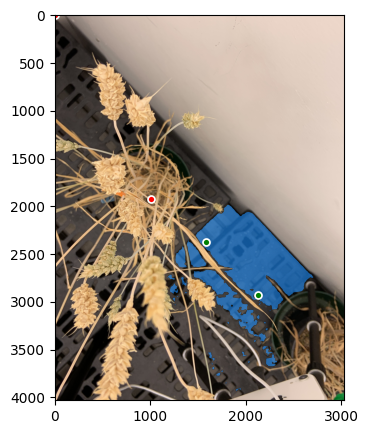

Reset? y/n y


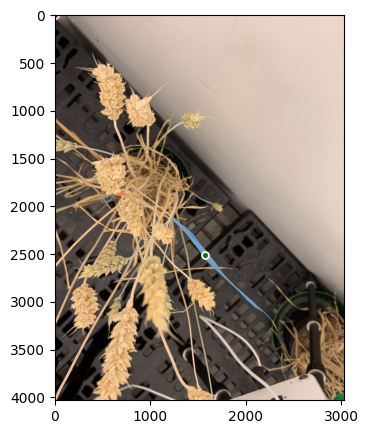

Done? y/n y


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../../../../Desktop/2024_stripe_rust/auto_segment/TH1R1_top/TH1R1_BigLab_iPhone14_20240507_024758_3680.png is a low contrast image
  return func(*args, **kwargs)


In [51]:
point_coors = [[0,0]]
point_labels = [0]
for leaf in leaves:
    print(leaf[0])

    image = cv2.imread(leaf[0])
    predictor.set_image(image)
    reset = False
    done = False
    mask = get_mask(np.array(point_coors),np.array(point_labels))
    reset_prompt = input('Reset? y/n')
    reset = True if reset_prompt == 'y' else False
    if not reset:
        done = True
    if reset:
        point_coors = [[0,0]]
        point_labels = [0]
    while not done:
        # displaying the image
        cv2.imshow('image', image)
        
        # setting mouse handler for the image
        # and calling the click_event() function
        new_label = ''
        new_point = []
        cv2.setMouseCallback('image', click_event)
        
        # wait for a key to be pressed to exit
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        cv2.waitKey(1)
        point_coors.append(new_point)
        point_labels.append(new_label)
        
        mask = get_mask(np.array(point_coors),np.array(point_labels))
        done_prompt = input('Done? y/n')
        done = True if done_prompt == 'y' else False
    
    masked_image = cv2.bitwise_and(image, image, mask=mask[0].astype(np.uint8))
    masked_image = cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB)
    
    io.imsave('../../../../Desktop/2024_stripe_rust/auto_segment/TH1R1_top/'+leaf[1][:-4]+'png', masked_image)
    for i in range(10):
        clear_output(wait=True)

[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


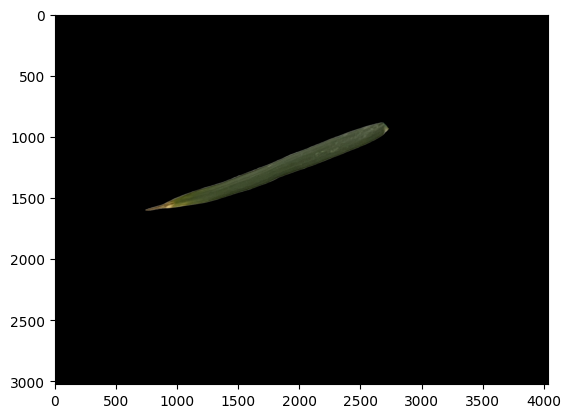

In [16]:
print(masked_image)
plt.imshow(masked_image)

In [49]:
import skimage.morphology as morph
import skimage.measure as measure
import pandas as pd
crops = []

directory = '../../auto_segment/Carberry-3/'
files = sorted(os.listdir(directory))
#files = ['Avocet-1_Green SkEye iPhone 18_20250221_130745_394.jpeg']

for file in files[:]:
    crops.append(directory+file)

In [50]:
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage.morphology import closing, footprint_rectangle
from skimage.color import label2rgb

for filename in crops[1:]:
    print(filename)
    # read in image
    image = cv2.imread(filename)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    #apply binary mask to seperate from black background
    binary_image = gray_image > 0
    # fill in small object

    # remove everything smaller than largest
    mask = morph.remove_small_objects(binary_image, 3600)
    masked_image = cv2.bitwise_and(image, image, mask=mask.astype(np.uint8))
    out = cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB)
    io.imsave(filename, out)

../../auto_segment/Carberry-3/Carberry-3_13Pro01_20250220_021149_284.jpeg


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-package

../../auto_segment/Carberry-3/Carberry-3_13Pro01_20250220_130149_651.jpeg
../../auto_segment/Carberry-3/Carberry-3_13Pro01_20250220_235150_056.jpeg


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-package

../../auto_segment/Carberry-3/Carberry-3_13Pro01_20250221_021150_126.jpeg
../../auto_segment/Carberry-3/Carberry-3_13Pro01_20250221_130150_276.jpeg
../../auto_segment/Carberry-3/Carberry-3_13Pro01_20250221_235150_464.jpeg


...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-package

../../auto_segment/Carberry-3/Carberry-3_13Pro01_20250317_130748_877.jpeg
../../auto_segment/Carberry-3/Carberry-3_13Pro01_20250317_235749_057.jpeg


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-package

../../auto_segment/Carberry-3/Carberry-3_13Pro01_20250318_021749_130.jpeg


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs


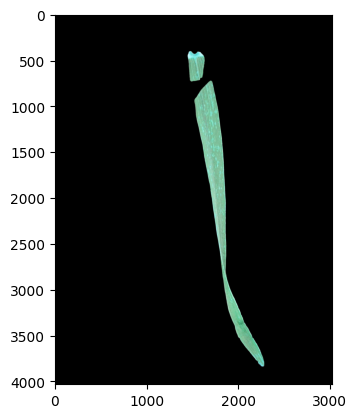